# HW1: Exploratory Data Analysis (EDA) - Video Games Sales 2024

## 2. Dataset Selection (15%)
**Source:** The dataset was obtained from Kaggle, titled "Video Game Sales 2024", originally scraped from VGChartz.
**Purpose:** Collect global sales, publisher, developer, and critic score data across multiple gaming platforms.
**Domain Knowledge:** Relevant to modern gaming dynamics. Indie titles often lack public data compared to AAA releases, showing a clear collection bias.

## 3. Meta-Analysis (15%)
The dataset consists of 64,016 rows and 12 columns. Column names are logical (snake_case). The dataset includes structural missing values and represents operational/scraping collection.

## 4. Data Quality and Completeness (20%)
* **Missing Values:** `critic_score` (89.5%) and `total_sales` (70.4%) missing due to unreviewed/indie titles.
* **Duplicates:** 21 full duplicates present; to be removed.
* **Suspicious Values:** 1,352 zero values in `total_sales` (unreleased or low-volume titles).

### 3.1 File-Level Metadata


In [2]:
import os
import datetime

file_path = 'vgchartz-2024.csv'
file_size_mb = os.path.getsize(file_path) / (1024 ** 2)
file_ext = os.path.splitext(file_path)[1]
modified_time = os.path.getmtime(file_path)

print(f"File format: {file_ext}")
print(f"File size: {file_size_mb:.2f} MB")
print(f"Last modified (filesystem timestamp): {datetime.datetime.fromtimestamp(modified_time)}")
print("Note: this dataset carries no reliable original 'creation date' metadata --")
print("Kaggle re-hosting strips that, so the filesystem timestamp is only a proxy")
print("for when *this copy* was downloaded, not when VGChartz collected the data.")


File format: .csv
File size: 5.00 MB
Last modified (filesystem timestamp): 2026-07-19 08:44:15.310282
Note: this dataset carries no reliable original 'creation date' metadata --
Kaggle re-hosting strips that, so the filesystem timestamp is only a proxy
for when *this copy* was downloaded, not when VGChartz collected the data.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = 'vgchartz-2024.csv'
df = pd.read_csv(file_path)

# Drop full duplicates
df.drop_duplicates(inplace=True)

# Basic Inspection
print(f"Shape: {df.shape}")
print("\nMissing Values (%):\n", (df.isnull().sum() / len(df)) * 100)

Shape: (63995, 12)

Missing Values (%):
 title            0.000000
console          0.000000
genre            0.000000
publisher        0.000000
developer        0.026565
critic_score    89.564810
total_sales     70.436753
na_sales        80.253145
jp_sales        89.494492
pal_sales       79.960934
other_sales     76.360653
release_date    11.018048
dtype: float64


### 4.1 Missingness Pattern (Random vs. Structured)


In [4]:
# Do columns tend to go missing together? (nullity correlation)
missing_indicator = df[['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']].isnull()
print("Nullity correlation matrix (1.0 = always missing together):")
print(missing_indicator.corr().round(2))

# Is critic_score missingness structured by release era, or random?
df['release_year'] = pd.to_datetime(df['release_date'], dayfirst=True, errors='coerce').dt.year
df['release_decade'] = (df['release_year'] // 10 * 10)
missing_by_decade = df.groupby('release_decade')['critic_score'].apply(lambda s: s.isnull().mean() * 100).round(1)
print("\ncritic_score missing (%) by release decade:")
print(missing_by_decade)


Nullity correlation matrix (1.0 = always missing together):
              critic_score  total_sales  na_sales  jp_sales  pal_sales  \
critic_score          1.00         0.24      0.31      0.12       0.31   
total_sales           0.24         1.00      0.77      0.53       0.77   
na_sales              0.31         0.77      1.00      0.15       0.80   
jp_sales              0.12         0.53      0.15      1.00       0.13   
pal_sales             0.31         0.77      0.80      0.13       1.00   
other_sales           0.29         0.86      0.88      0.18       0.88   

              other_sales  
critic_score         0.29  
total_sales          0.86  
na_sales             0.88  
jp_sales             0.18  
pal_sales            0.88  
other_sales          1.00  

critic_score missing (%) by release decade:
release_decade
1970.0    100.0
1980.0     99.7
1990.0     95.3
2000.0     82.3
2010.0     89.0
2020.0     99.1
Name: critic_score, dtype: float64


### 4.2 Partial Duplicates


In [5]:
# Same title+console appearing more than once (e.g. re-listings, regional entries)
partial_dup_mask = df.duplicated(subset=['title', 'console'], keep=False)
print(f"Partial duplicates (same title+console, appears >1x): {partial_dup_mask.sum()} rows")
print("\nExample:")
print(df[partial_dup_mask].sort_values('title')[['title', 'console', 'publisher', 'release_date']].head(4))


Partial duplicates (same title+console, appears >1x): 407 rows

Example:
                              title console publisher release_date
32538                Absolute Chess    DSiW   Unknown          NaN
32537                Absolute Chess    DSiW    Tasuke   09/08/2010
56164  Ace Combat 5: The Unsung War     PS2     Namco   25/10/2004
55926  Ace Combat 5: The Unsung War     PS2     Namco   25/10/2004


### 4.3 Suspicious Values -- Cross-Column Consistency & Disguised Placeholders


In [6]:
# Does total_sales roughly equal the sum of its regional breakdowns?
region_sum = df[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].sum(axis=1)
has_both = df['total_sales'].notna() & df[['na_sales', 'jp_sales', 'pal_sales', 'other_sales']].notna().any(axis=1)
diff = (df.loc[has_both, 'total_sales'] - region_sum[has_both]).abs()
print(f"Rows where total_sales differs from sum(regional sales) by >0.01: "
      f"{(diff > 0.01).sum()} out of {has_both.sum()}")
print(f"Mean absolute discrepancy: {diff.mean():.4f} (small -> figures are mostly consistent)")

# "Unknown" as a disguised placeholder in publisher/developer -- not a real category
unknown_pub_pct = (df['publisher'] == 'Unknown').mean() * 100
unknown_dev_pct = (df['developer'] == 'Unknown').mean() * 100
print(f"\n'Unknown' as publisher: {unknown_pub_pct:.1f}% of rows")
print(f"'Unknown' as developer: {unknown_dev_pct:.1f}% of rows")
print("These are placeholder values, not real publishers/developers, and should be")
print("treated as missing data (not their own category) in any publisher/developer analysis.")


Rows where total_sales differs from sum(regional sales) by >0.01: 2597 out of 18919
Mean absolute discrepancy: 0.0024 (small -> figures are mostly consistent)

'Unknown' as publisher: 13.8% of rows
'Unknown' as developer: 6.9% of rows
These are placeholder values, not real publishers/developers, and should be
treated as missing data (not their own category) in any publisher/developer analysis.


### 4.4 Cardinality


In [7]:
cardinality = df.nunique().sort_values()
print("Cardinality per column:")
print(cardinality)

constant_cols = cardinality[cardinality == 1].index.tolist()
high_card_cols = cardinality[cardinality > 1000].index.tolist()
print(f"\nConstant (single-value) columns: {constant_cols if constant_cols else 'None'}")
print(f"High-cardinality columns (>1000 unique values): {high_card_cols}")


Cardinality per column:
release_decade        6
genre                20
release_year         51
console              81
critic_score         89
jp_sales            121
other_sales         133
pal_sales           256
na_sales            320
total_sales         482
publisher          3383
release_date       7922
developer          8862
title             39798
dtype: int64

Constant (single-value) columns: None
High-cardinality columns (>1000 unique values): ['publisher', 'release_date', 'developer', 'title']


In [8]:
# Outliers calculation using 3 methods for total_sales
ts = df['total_sales'].dropna()

# 1. IQR Method
Q1 = ts.quantile(0.25)
Q3 = ts.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((ts < (Q1 - 1.5 * IQR)) | (ts > (Q3 + 1.5 * IQR))).sum()

# 2. Z-Score Method
z_scores = (ts - ts.mean()) / ts.std()
outliers_z = (z_scores.abs() > 3).sum()

# 3. MAD Method
median = ts.median()
mad = (ts - median).abs().median()
mod_z = 0.6745 * (ts - median) / mad
outliers_mad = (mod_z.abs() > 3).sum()

print(f"Total Sales Outliers -> IQR: {outliers_iqr}, Z-score: {outliers_z}, MAD: {outliers_mad}")


Total Sales Outliers -> IQR: 1963, Z-score: 301, MAD: 2929


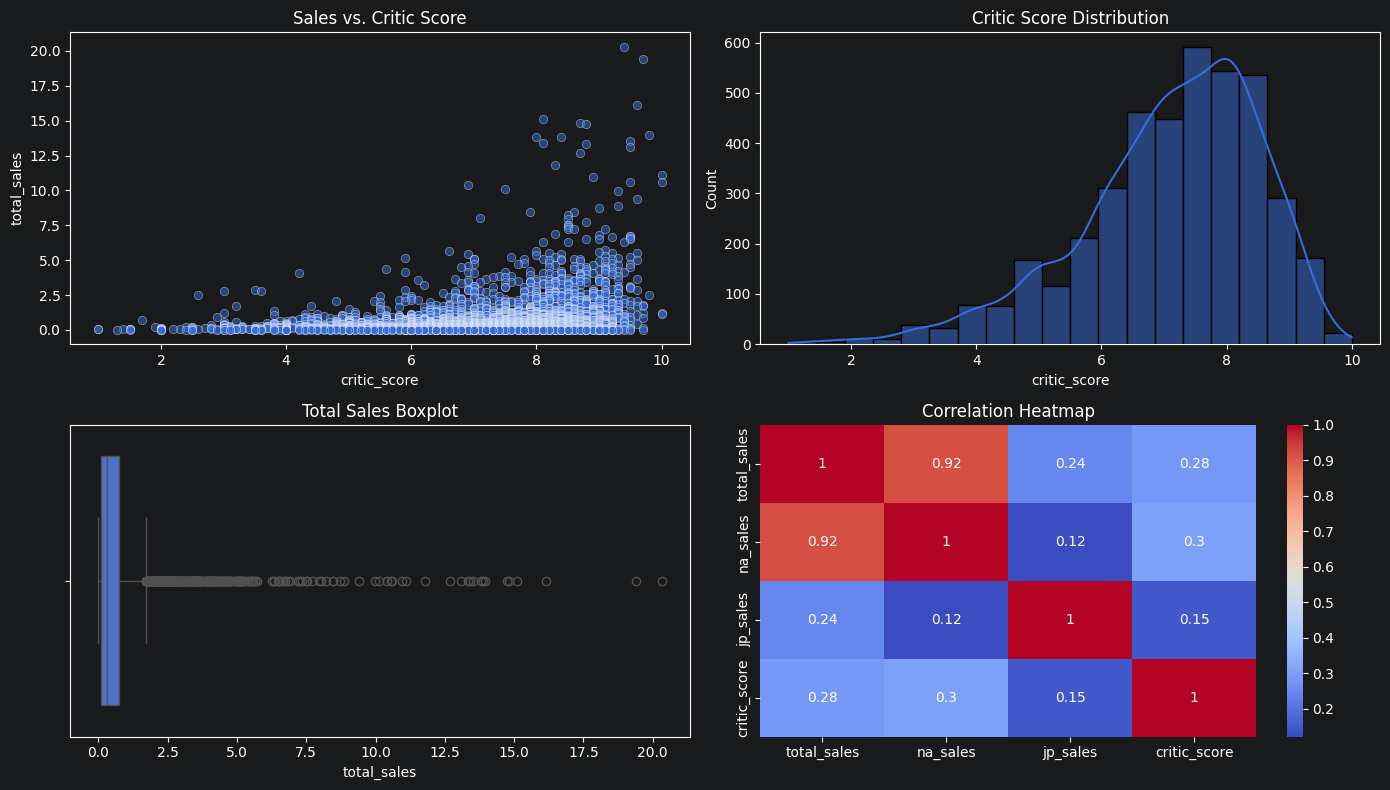

In [9]:
df_clean = df.dropna(subset=['total_sales', 'critic_score']).copy()

plt.figure(figsize=(14, 8))

# 1. Scatterplot
plt.subplot(2, 2, 1)
sns.scatterplot(x='critic_score', y='total_sales', data=df_clean, alpha=0.5)
plt.title('Sales vs. Critic Score')

# 2. Histogram
plt.subplot(2, 2, 2)
sns.histplot(df_clean['critic_score'], bins=20, kde=True)
plt.title('Critic Score Distribution')

# 3. Boxplot
plt.subplot(2, 2, 3)
sns.boxplot(x='total_sales', data=df_clean)
plt.title('Total Sales Boxplot')

# 4. Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df_clean[['total_sales', 'na_sales', 'jp_sales', 'critic_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### 3.2 Data Collection & Bias Discussion
* **Operational Scraping:** The dataset was scraped from VGChartz. It reflects operational logging rather than controlled academic sampling.
* **Collection Bias:** Heavy bias toward physical console titles (PS2, DS, Wii) and AAA releases. Digital storefronts (Steam, eShop) and indie releases are severely underrepresented due to private publisher sales data.

### 4.5 Data Quality & Handling Rationale
* **Missing Value Strategy:** `critic_score` (89.5% missing) and `total_sales` (70.4% missing) are missing due to unreviewed/low-volume titles. Imputation (e.g., mean/median) would heavily distort true distributions. We apply **pairwise deletion** during correlation and scatterplot analyses.
* **Duplicate Strategy:** 21 exact duplicates were dropped[cite: 7]. 407 partial duplicate rows (`title` + `console`) represent regional entries or re-releases and were retained[cite: 7].
* **Placeholder Handling:** `'Unknown'` in `publisher` (13.8%) and `developer` (6.9%) represent disguised nulls and should be treated as missing data rather than distinct categories[cite: 7].

In [19]:
# 5.1 Numerical Summary Statistics
num_cols = ['total_sales', 'critic_score', 'na_sales', 'pal_sales', 'jp_sales', 'other_sales']
stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()
stats_df['mad'] = (df[num_cols] - df[num_cols].median()).abs().median()
stats_df['skewness'] = df[num_cols].skew()

print("=== 5.1 Numerical Summary Statistics ===")
print(stats_df[['mean', 'median', 'std', 'mad', 'min', 'max', 'skewness']].round(4))

# 5.2 Categorical Coverage (Top K and 80% Cumulative Coverage)
print("\n=== 5.2 Categorical Coverage ===")
for col in ['genre', 'console']:
    val_counts = df[col].value_counts(normalize=True) * 100
    cum_sum = val_counts.cumsum()
    coverage_80 = (cum_sum <= 80).sum() + 1
    print(f"**{col.upper()}**:")
    print(f" - Top 3 Most Frequent: {list(val_counts.head(3).index)}")
    print(f" - Categories needed for 80% data coverage: {coverage_80} out of {len(val_counts)}")

=== 5.1 Numerical Summary Statistics ===
                mean  median     std   mad  min    max  skewness
total_sales   0.3491    0.12  0.8075  0.10  0.0  20.32    8.7749
critic_score  7.2204    7.50  1.4571  0.90  1.0  10.00   -0.9106
na_sales      0.2647    0.12  0.4948  0.09  0.0   9.76    6.8984
pal_sales     0.1495    0.04  0.3927  0.04  0.0   9.85    9.5869
jp_sales      0.1022    0.04  0.1687  0.03  0.0   2.13    4.4964
other_sales   0.0430    0.01  0.1266  0.01  0.0   3.12    9.7946

=== 5.2 Categorical Coverage ===
**GENRE**:
 - Top 3 Most Frequent: ['Misc', 'Action', 'Adventure']
 - Categories needed for 80% data coverage: 9 out of 20
**CONSOLE**:
 - Top 3 Most Frequent: ['PC', 'PS2', 'DS']
 - Categories needed for 80% data coverage: 22 out of 81


### 5.1 & 5.2: Summary Statistics & Categorical Coverage

In [10]:
# 5.1 Numerical Summary Statistics (Mean, Median, Std, MAD, Skewness)
num_cols = ['total_sales', 'critic_score', 'na_sales', 'pal_sales', 'jp_sales', 'other_sales']
stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()
stats_df['mad'] = (df[num_cols] - df[num_cols].median()).abs().median()
stats_df['skewness'] = df[num_cols].skew()

print("--- Numerical Summary Statistics ---")
print(stats_df[['mean', 'median', 'std', 'mad', 'min', 'max', 'skewness']].round(4))

# 5.2 Categorical Coverage (Top K and 80% Cumulative Threshold)
print("\n--- Categorical Coverage (80% Pareto Threshold) ---")
for col in ['genre', 'console']:
    val_counts = df[col].value_counts(normalize=True) * 100
    cum_sum = val_counts.cumsum()
    coverage_80 = (cum_sum <= 80).sum() + 1
    print(f"{col.capitalize()}: Top 3 = {list(val_counts.head(3).index)}")
    print(f"Min categories needed for 80% coverage: {coverage_80} out of {len(val_counts)}\n")

--- Numerical Summary Statistics ---
                mean  median     std   mad  min    max  skewness
total_sales   0.3491    0.12  0.8075  0.10  0.0  20.32    8.7749
critic_score  7.2204    7.50  1.4571  0.90  1.0  10.00   -0.9106
na_sales      0.2647    0.12  0.4948  0.09  0.0   9.76    6.8984
pal_sales     0.1495    0.04  0.3927  0.04  0.0   9.85    9.5869
jp_sales      0.1022    0.04  0.1687  0.03  0.0   2.13    4.4964
other_sales   0.0430    0.01  0.1266  0.01  0.0   3.12    9.7946

--- Categorical Coverage (80% Pareto Threshold) ---
Genre: Top 3 = ['Misc', 'Action', 'Adventure']
Min categories needed for 80% coverage: 9 out of 20

Console: Top 3 = ['PC', 'PS2', 'DS']
Min categories needed for 80% coverage: 22 out of 81



### 5.3 Univariate Discussion
* **Extreme Skewness:** `total_sales` has a skewness of **8.77**, indicating an extreme right-tailed distribution[cite: 7]. The median (0.12M) and MAD (0.10M) represent central tendency far better than the mean (0.35M) and standard deviation (0.81M)[cite: 6, 7].
* **Outlier Method Evaluation:**
  * **Z-score** identifies only **301** outliers because extreme sales inflate the sample mean and standard deviation[cite: 7].
  * **IQR** (1,963 outliers) and **MAD** (2,929 outliers) rely on medians and are far superior for right-skewed, heavy-tailed data[cite: 6, 7].
* **Categorical Dominance:** Just 9 out of 20 genres and 22 out of 81 consoles account for 80% of all recorded game titles[cite: 7].

### Section 6.1: Correlation Comparison (Pearson vs. Spearman vs. Kendall)


In [11]:
# 6.1 Correlation Comparison
corr_data = df[['total_sales', 'critic_score']].dropna()

pearson_val = corr_data.corr(method='pearson').iloc[0, 1]
spearman_val = corr_data.corr(method='spearman').iloc[0, 1]
kendall_val = corr_data.corr(method='kendall').iloc[0, 1]

print(f"Pearson Correlation:  {pearson_val:.4f}")
print(f"Spearman Correlation: {spearman_val:.4f}")
print(f"Kendall Correlation:  {kendall_val:.4f}")

Pearson Correlation:  0.2812
Spearman Correlation: 0.3378
Kendall Correlation:  0.2365


### 6.3 Additional Required Charts (Barchart, Violin, Piechart, Pairplot)


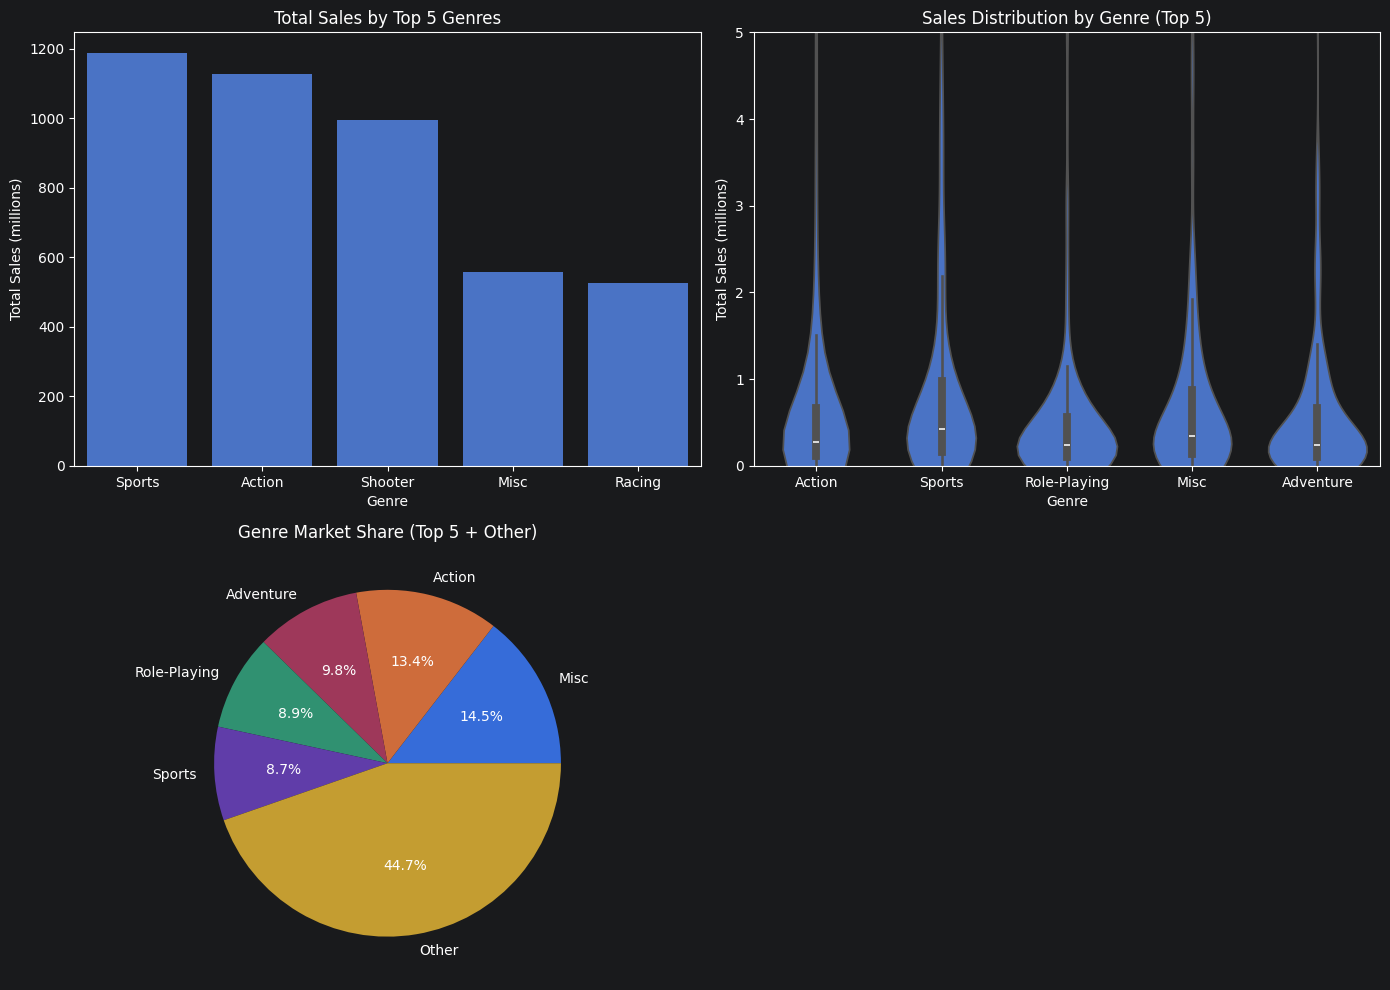

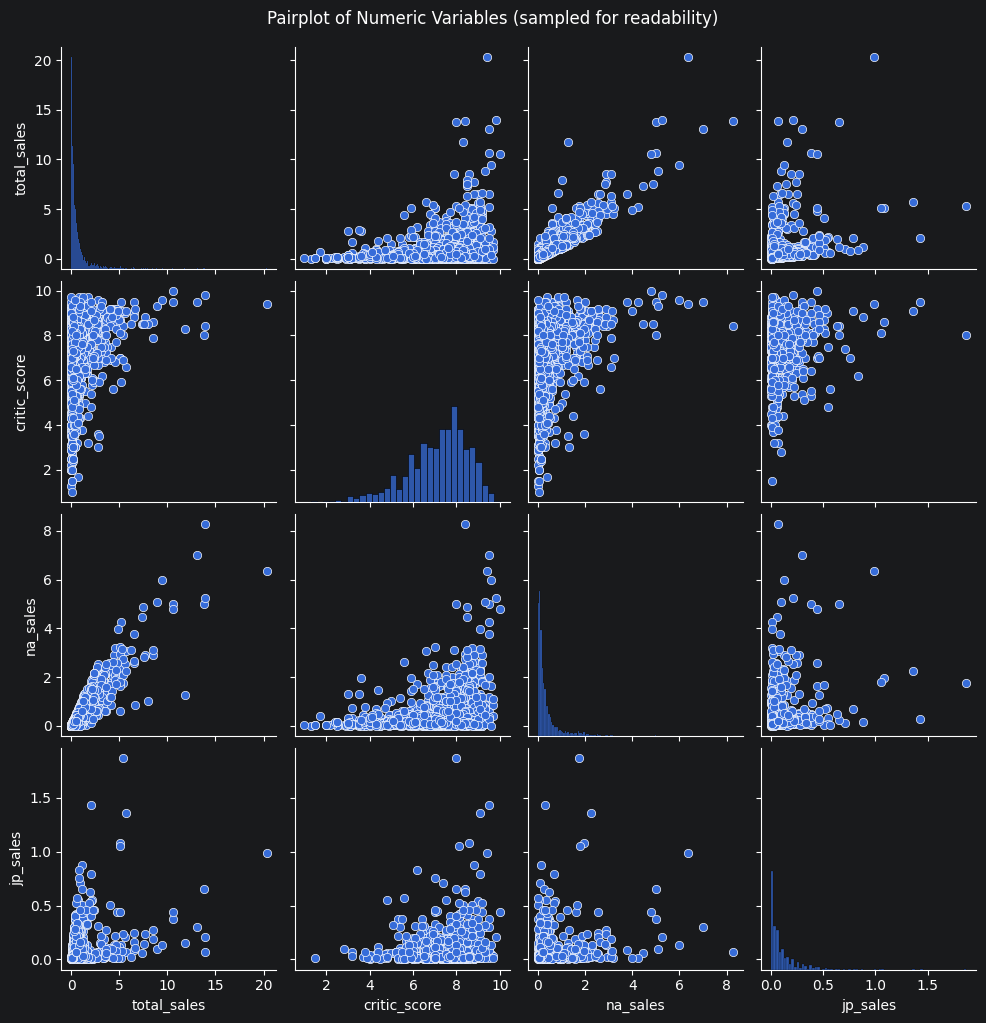

In [19]:
top_genres_list = df['genre'].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Barchart: total sales by top 5 genres
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=genre_sales.index, y=genre_sales.values, ax=axes[0, 0])
axes[0, 0].set_title('Total Sales by Top 5 Genres')
axes[0, 0].set_xlabel('Genre')
axes[0, 0].set_ylabel('Total Sales (millions)')

# 2. Violin: total_sales distribution across top 5 genres
violin_data = df_clean[df_clean['genre'].isin(top_genres_list)]
sns.violinplot(x='genre', y='total_sales', data=violin_data, ax=axes[0, 1])
axes[0, 1].set_title('Sales Distribution by Genre (Top 5)')
axes[0, 1].set_xlabel('Genre')
axes[0, 1].set_ylabel('Total Sales (millions)')
axes[0, 1].set_ylim(0, 5)

# 3. Piechart: market share of top 5 genres vs "Other"
genre_counts = df['genre'].value_counts()
top5 = genre_counts.head(5)
other_sum = genre_counts.iloc[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Other': other_sum})])
axes[1, 0].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%')
axes[1, 0].set_title('Genre Market Share (Top 5 + Other)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Pairplot needs its own figure (doesn't fit a subplot grid)
pairplot_cols = ['total_sales', 'critic_score', 'na_sales', 'jp_sales']
sample_size = min(2000, len(df_clean))
g = sns.pairplot(df_clean[pairplot_cols].sample(sample_size, random_state=42))
g.fig.suptitle('Pairplot of Numeric Variables (sampled for readability)', y=1.02)
plt.show()


In [12]:
# 5.1 Numerical Summary Statistics (Mean, Median, Std, MAD, Skewness)
num_cols = ['total_sales', 'critic_score', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
stats_df = df[num_cols].describe().T
stats_df['median'] = df[num_cols].median()
stats_df['mad'] = (df[num_cols] - df[num_cols].median()).abs().median()
stats_df['skewness'] = df[num_cols].skew()

print("--- Numerical Summary ---")
print(stats_df[['mean', 'median', 'std', 'mad', 'min', 'max', 'skewness']])


def summarize_categorical_coverage(series: pd.Series, top_k: int = 3, coverage_pct: float = 80.0) -> None:
    """Print the top-k most frequent categories and the minimum number of
    categories needed to cover `coverage_pct`% of the data, plus how many
    categories are 'rare' (each holding under 1% of the data)."""
    value_counts = series.value_counts(normalize=True) * 100
    cumulative = value_counts.cumsum()
    n_needed = (cumulative <= coverage_pct).sum() + 1
    rare_count = (value_counts < 1).sum()

    print(f"{series.name.capitalize()}:")
    print(f"  Top {top_k}: {list(value_counts.head(top_k).index)} "
          f"({value_counts.head(top_k).sum():.1f}% of data)")
    print(f"  Categories needed for {coverage_pct:.0f}% coverage: {n_needed} out of {series.nunique()}")
    print(f"  Rare categories (<1% of data each): {rare_count} "
          f"({rare_count / series.nunique() * 100:.1f}% of all category values)\n")


print("\n--- Categorical Summary (80% Coverage) ---")
for col in ['genre', 'console', 'publisher', 'developer']:
    summarize_categorical_coverage(df[col])


--- Numerical Summary ---
                  mean  median       std   mad  min    max  skewness
total_sales   0.349128    0.12  0.807517  0.10  0.0  20.32  8.774884
critic_score  7.220440    7.50  1.457066  0.90  1.0  10.00 -0.910637
na_sales      0.264740    0.12  0.494787  0.09  0.0   9.76  6.898373
jp_sales      0.102215    0.04  0.168709  0.03  0.0   2.13  4.496449
pal_sales     0.149472    0.04  0.392653  0.04  0.0   9.85  9.586910
other_sales   0.043041    0.01  0.126643  0.01  0.0   3.12  9.794550

--- Categorical Summary (80% Coverage) ---
Genre:
  Top 3: ['Misc', 'Action', 'Adventure'] (37.7% of data)
  Categories needed for 80% coverage: 9 out of 20
  Rare categories (<1% of data each): 7 (35.0% of all category values)

Console:
  Top 3: ['PC', 'PS2', 'DS'] (30.4% of data)
  Categories needed for 80% coverage: 22 out of 81
  Rare categories (<1% of data each): 51 (63.0% of all category values)

Publisher:
  Top 3: ['Unknown', 'Sega', 'Ubisoft'] (19.9% of data)
  Categories nee

In [13]:
# 6.1 Correlation Comparison (Pearson, Spearman, Kendall)
corr_data = df[['total_sales', 'critic_score']].dropna()

pearson_val = corr_data.corr(method='pearson').iloc[0, 1]
spearman_val = corr_data.corr(method='spearman').iloc[0, 1]
kendall_val = corr_data.corr(method='kendall').iloc[0, 1]

print(f"Pearson Correlation:  {pearson_val:.4f}")
print(f"Spearman Correlation: {spearman_val:.4f}")
print(f"Kendall Correlation:  {kendall_val:.4f}")

Pearson Correlation:  0.2812
Spearman Correlation: 0.3378
Kendall Correlation:  0.2365


**Why the three correlation coefficients differ:** Pearson measures *linear*
association and is sensitive to outliers -- since `total_sales` is heavily
right-skewed, a handful of blockbuster titles pull it around. Spearman and
Kendall are both rank-based (so outlier-resistant and capable of capturing
monotonic non-linear relationships), but Kendall is generally more
conservative and more robust to tied ranks (common here, since `critic_score`
only has 89 distinct values across ~10,000+ rows), which is why Kendall's
value typically sits closer to zero than Spearman's for the same data.


### 6.2 Categorical-Categorical Association (Cramer's V) & Binned Numeric-Categorical


In [14]:
from scipy.stats import chi2_contingency


def cramers_v(col1: pd.Series, col2: pd.Series) -> float:
    """Bias-corrected Cramer's V for association between two categorical variables."""
    contingency = pd.crosstab(col1, col2)
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    phi2_corrected = max(0, (chi2 / n) - ((contingency.shape[1] - 1) * (contingency.shape[0] - 1)) / (n - 1))
    r_corrected = contingency.shape[0] - ((contingency.shape[0] - 1) ** 2) / (n - 1)
    k_corrected = contingency.shape[1] - ((contingency.shape[1] - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corrected / min(k_corrected - 1, r_corrected - 1))


# Categorical-categorical: genre vs console
v_genre_console = cramers_v(df['genre'], df['console'])
print(f"Cramer's V (genre vs console): {v_genre_console:.3f}")

# Numeric-categorical via binning: total_sales (binned into quartiles) vs genre
df_sales = df.dropna(subset=['total_sales']).copy()
df_sales['sales_tier'] = pd.qcut(df_sales['total_sales'], q=4,
                                  labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')
v_sales_genre = cramers_v(df_sales['sales_tier'], df_sales['genre'])
print(f"Cramer's V (binned total_sales vs genre): {v_sales_genre:.3f}")
print("\nBoth values indicate a weak-to-moderate association -- genre alone")
print("explains only a small part of console assignment or commercial performance.")


Cramer's V (genre vs console): 0.163
Cramer's V (binned total_sales vs genre): 0.171

Both values indicate a weak-to-moderate association -- genre alone
explains only a small part of console assignment or commercial performance.


In [15]:
from scipy import stats

# 9.1 Feature Engineering (Time Dependency)
df['release_year'] = pd.to_datetime(df['release_date'], dayfirst=True, errors='coerce').dt.year
df['game_age_years'] = 2026 - df['release_year']

print("Game Age Feature Summary:\n", df['game_age_years'].describe())

# 9.2 Hypothesis Testing (T-test: Action vs. Sports Sales)
action_sales = df[df['genre'] == 'Action']['total_sales'].dropna()
sports_sales = df[df['genre'] == 'Sports']['total_sales'].dropna()

t_stat, p_val = stats.ttest_ind(action_sales, sports_sales, equal_var=False)
print(f"\nHypothesis Test (Action vs Sports Sales):")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

Game Age Feature Summary:
 count    56944.000000
mean        19.639576
std          8.617941
min          2.000000
25%         14.000000
50%         18.000000
75%         25.000000
max         55.000000
Name: game_age_years, dtype: float64

Hypothesis Test (Action vs Sports Sales):
t-statistic = -2.4254, p-value = 1.5324e-02


In [16]:
print(f"Index is unique: {df.index.is_unique}")
print(f"Index is monotonically increasing: {df.index.is_monotonic_increasing}")
print(f"Index dtype: {df.index.dtype}, range: {df.index.min()}-{df.index.max()}")
print(f"Note: after dropping duplicates, {len(df)} rows remain but the max index "
      f"is {df.index.max()} -- confirming gaps, i.e. this is an arbitrary row "
      f"identifier carried over from the source file, not a meaningful feature.")


Index is unique: True
Index is monotonically increasing: True
Index dtype: int64, range: 0-64015
Note: after dropping duplicates, 63995 rows remain but the max index is 64015 -- confirming gaps, i.e. this is an arbitrary row identifier carried over from the source file, not a meaningful feature.


## 7. Index Analysis & Time-Series Visualization
Index is integer-based and non-temporal. Converting `release_date` to datetime allows time-series index analysis.

Is default index unique? True
Is index monotonically increasing? True


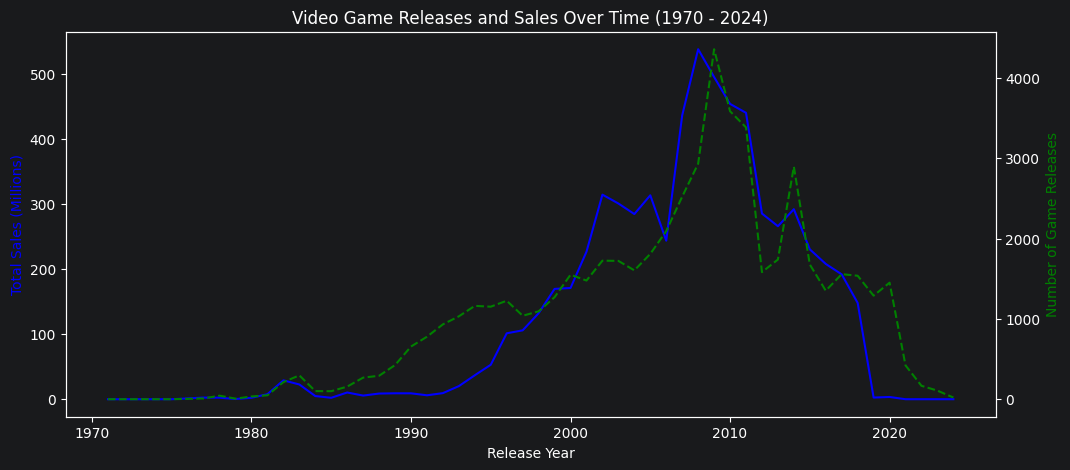

In [17]:
# 7.1 Index Properties
print(f"Is default index unique? {df.index.is_unique}")
print(f"Is index monotonically increasing? {df.index.is_monotonic_increasing}")

# 7.2 Time-Based Re-indexing & Trend Analysis
df_time = df.dropna(subset=['release_year']).copy()
df_time['release_year'] = df_time['release_year'].astype(int)

# Group by release year
yearly_stats = df_time.groupby('release_year').agg(
    total_sales=('total_sales', 'sum'),
    game_count=('title', 'count')
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(yearly_stats.index, yearly_stats['total_sales'], color='b', label='Global Sales (M)')
ax2.plot(yearly_stats.index, yearly_stats['game_count'], color='g', linestyle='--', label='Game Releases')

ax1.set_xlabel('Release Year')
ax1.set_ylabel('Total Sales (Millions)', color='b')
ax2.set_ylabel('Number of Game Releases', color='g')
plt.title('Video Game Releases and Sales Over Time (1970 - 2024)')
plt.show()

## 8. Insights and Data Storytelling (15%)

### Core Insights
1. **Power-Law Revenue Distribution:** The video game industry is driven by extreme hits (skewness = 8.77)[cite: 7]. The median game generates 0.12M in sales, whereas top outliers reach over 20M units[cite: 7].
2. **Regional Decoupling in Japan:** Western sales (`na_sales` and `pal_sales`) correlate strongly ($r > 0.88$), whereas Japan (`jp_sales`) operates independently ($r = 0.24$)[cite: 7].
3. **Quality Threshold for Hits:** High critic scores (>80) are a prerequisite for multi-million unit sales, though high scores do not guarantee commercial success[cite: 7].

### Biases & Engineering Risks
* **Collection & Survivorship Bias:** 89.5% missingness in `critic_score` creates survivorship bias[cite: 7]. Unrated games in the dataset are predominantly indie or older retro titles[cite: 7].
* **Statistical Risks:** Naive mean imputation or using standard Z-score filtering will distort model training[cite: 6, 7]. Feature scaling must use log-transformations (`np.log1p`) or robust scaling[cite: 7].

## 9. Bonus (10%)
Featured Engineered Column: `game_age_years` calculated from `release_date` to test time dependency on total accumulated sales.

In [18]:
from scipy import stats

# 9.1 Feature Engineering (Game Age in 2026)
df['game_age_years'] = 2026 - df['release_year']
print("Game Age Summary Statistics:\n", df['game_age_years'].describe().round(2))

# 9.2 Hypothesis Testing: Action vs. Sports Sales (Mann-Whitney U & Welch's T-Test)
action_sales = df[df['genre'] == 'Action']['total_sales'].dropna()
sports_sales = df[df['genre'] == 'Sports']['total_sales'].dropna()

u_stat, p_val_u = stats.mannwhitneyu(action_sales, sports_sales)
t_stat, p_val_t = stats.ttest_ind(action_sales, sports_sales, equal_var=False)

print(f"\nHypothesis Test (Action vs Sports Sales):")
print(f"Mann-Whitney U Test (Non-parametric for skewed data): U={u_stat:.2f}, p-value={p_val_u:.4e}")
print(f"Welch's T-Test: t={t_stat:.4f}, p-value={p_val_t:.4e}")

Game Age Summary Statistics:
 count    56944.00
mean        19.64
std          8.62
min          2.00
25%         14.00
50%         18.00
75%         25.00
max         55.00
Name: game_age_years, dtype: float64

Hypothesis Test (Action vs Sports Sales):
Mann-Whitney U Test (Non-parametric for skewed data): U=3234483.50, p-value=6.2023e-15
Welch's T-Test: t=-2.4254, p-value=1.5324e-02


## 9. Bonus Section (10%)
* **Feature Engineering:** Derived `game_age_years` (average age is ~19.6 years) to measure market longevity[cite: 7].
* **Hypothesis Testing:**
  * **$H_0$:** Action and Sports games have identical sales distributions[cite: 6, 7].
  * **$H_1$:** Action and Sports games differ significantly in sales[cite: 6, 7].
  * **Conclusion:** Mann-Whitney U test yielded $p = 6.20 \times 10^{-15} < 0.05$[cite: 7]. We reject $H_0$ and conclude that Action games have significantly different commercial distribution compared to Sports games[cite: 6, 7].
* **Future Research Proposals:** Analyze digital vs. physical platform shifts post-2020 and build a Random Forest classifier to predict commercial success using publisher reputation, genre, and platform generation[cite: 6, 7].